# Calculating the EKE along the contour - Panan $0.1^o$

A previous analysis of the CSHT between simulations of different horizontal resolutions show that increasing the resolution do not increase the Cross-slope heat transport. However, the spatial pattern of the heat transport changes, with some regions importing more heat towards the shelf, and others exporting more heat. Perhaps as we change resolution, the CSHT from eddies increase in some regions and decrease in others, explaining the displacement. We willt ry to cross reference the CSHT with the EKE along the isobath. For that, we will need to calculate the EKE along the contour



this code calcualtes the EKE along the contour and save the values into netcdfs

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client(threads_per_worker = 1)

2025-01-28 12:05:20,701 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:42031'.
2025-01-28 12:05:20,731 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:34935'.
2025-01-28 12:05:20,732 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:37863'.
2025-01-28 12:05:20,803 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,818 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,820 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,824 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,830 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,859 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,872 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,911 - distributed.nanny - WARNING - Restarting worker
2025-01-28 12:05:20,9

In [3]:
session = cc.database.create_session('/home/156/wf4500/databases/access/panan01_HTsigma.db') #panan01

imm= 12
monthdays = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month = str(int(imm))
month = month.zfill(2)
year = str(2000)
start_time=year+'-'+month  

start_time0=year+'-'+month +'-01'     
end_time0=year+'-'+month +'-' + str(monthdays[int(int(imm)-1)])
print(start_time0) 
print(end_time0) 
exp = 'panan01_yr2000_HTsigma'

print("Start date =" + start_time) 
year2=str(int(start_time[0:4])+1)
month2=str(int(start_time[5:7])+1)
month2=str(int(month2))
month2 = month2.zfill(2)    
print("month2 is =" + month2) 
print("year2 is =" + str(year2))     

imon = int(imm)
if imon <12:
	end_time=year+'-'+month2
else:
	end_time=year2+'-01'

print("End date =" + end_time) 


time_period = str(int(start_time[:4]))+'-'+str(int(end_time[:4]))

# reference density value:
rho_0 = 1035.0
# specific heat capacity of sea water:
cp = 3992.1
lat_range = slice(-90,-59)

isobath_depth = 1000

# pick a freezing point temp:
temp_freezing = -1.9

2000-12-01
2000-12-31
Start date =2000-12
month2 is =13
year2 is =2001
End date =2001-01


In [4]:
#Getting mass transport in kg/s
vmo_nt = cc.querying.getvar(exp,'vmo',session,ncfile='%month_rho%',start_time=start_time,end_time=end_time,chunks={}).sel(time=slice(start_time,end_time))
umo_et = cc.querying.getvar(exp,'umo',session,ncfile='%month_rho%',start_time=start_time,end_time=end_time,chunks={}).sel(time=slice(start_time,end_time))

vmo_nt = vmo_nt.sel(yq=lat_range).sel(time=slice(start_time0,end_time0))
umo_et = umo_et.sel(yh=lat_range).sel(time=slice(start_time0,end_time0))
vmo_nttime=vmo_nt.time


#importing volume
vol_centre = cc.querying.getvar(exp,'volcello',session,ncfile='%month_rho2.nc',start_time=start_time,end_time=end_time,chunks={})\
.sel(time=slice(start_time,end_time)).sel(yh=lat_range).sel(time=slice(start_time0,end_time0))

In [5]:
#Making volume on xq and yq grid  ######

#First making a halo for proper edges interpolation
lon_interval = vol_centre.xh.diff('xh').mean()
lon_rightappend = vol_centre.xh[-1].values+np.cumsum([lon_interval,lon_interval,lon_interval,lon_interval,lon_interval])
lon_leftappend = vol_centre.xh[0].values - \
np.flip(np.cumsum([lon_interval,lon_interval,lon_interval,lon_interval]))

newlon = np.concatenate((lon_leftappend,vol_centre.xh.values,lon_rightappend), axis=0)
vol_centre_halo = xr.concat([vol_centre.isel(xh=slice(-5,-1)),vol_centre,vol_centre.isel(xh=slice(0,5))], dim='xh')
vol_centre_halo['xh'] = newlon


#Now interpolating volumes onto the xq and yq grids
vol_yhxq = vol_centre_halo.interp(xh=umo_et.xq)
vol_yqxq = vol_centre_halo.interp(xh=umo_et.xq,yh=vmo_nt.yq)
vol_yqxh = vol_centre_halo.interp(yh=vmo_nt.yq)
vol_yhxh = vol_centre.copy()

importing dxt to calculate u velocity, and dyt to calculate v velocity and defining the boussinesq velocity

In [6]:
#dxs in all grid points
dx_xhyh = cc.querying.getvar(exp,'dxt',session,ncfile='19990101.ocean_static.nc')
dx_xqyh = cc.querying.getvar(exp,'dxCu',session,ncfile='19990101.ocean_static.nc')
dx_xhyq = cc.querying.getvar(exp,'dxCv',session,ncfile='19990101.ocean_static.nc')
dx_xqyq = dx_xhyh.rename({'xh':'xq','yh':'yq'}).copy()
dx_xqyq=  xr.concat([dx_xqyq[:,-1],dx_xqyq], dim='xq')
dx_xqyq['yq'] = dx_xhyq.yq[:-1]
dx_xqyq['xq'] = dx_xqyh.xq

#dys in all grid points
dy_xhyh = cc.querying.getvar(exp,'dyt',session,ncfile='19990101.ocean_static.nc')
dy_xqyh = cc.querying.getvar(exp,'dyCu',session,ncfile='19990101.ocean_static.nc')
dy_xhyq = cc.querying.getvar(exp,'dyCv',session,ncfile='19990101.ocean_static.nc')
dy_xqyq = dy_xhyh.rename({'xh':'xq','yh':'yq'}).copy()
dy_xqyq=  xr.concat([dy_xqyq[:,-1],dy_xqyq], dim='xq')
dy_xqyq['yq'] = dy_xhyq.yq[:-1]
dy_xqyq['xq'] = dy_xqyh.xq

#setting the reference rho
rho_ref = 1035 #kg m^{-3}, used as standard by Pan-Antarctic

We will calculate $U$ speeds by:

$$
  U(xq,yh,\sigma)\ =\ {umo} \times \rho^{-1} \times {Vol}^{-1}_{(xq,yh)} \times dxt_{(xq,yh)} \ \ \ [m\ s^{-1}]
$$

and $V$ speeds by:

$$
  V(xh,yq,\sigma)\ =\ {vmo} \times \rho^{-1} \times {Vol}^{-1}_{(xh,yq)} \times dyt_{(xh,yq)} \ \ \ [m\ s^{-1}]
$$

In [7]:
#first for U
U_xq = (umo_et*(1/rho_ref) * (1/vol_yhxq) * dx_xqyh).compute()

#now for V
V_yq = (vmo_nt*(1/rho_ref) * (1/vol_yqxh) * dy_xhyq).compute()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in div

In [8]:
U_xq = U_xq.drop_vars('xh').where(U_xq>-9e10).where(U_xq<9e10)
V_yq  = V_yq .drop_vars('yh').where(V_yq>-9e10).where(V_yq<9e10)

Caclculating U and V anomalies

In [9]:
U_qmean=xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/EKE_along_contour_rho/U_mean_1999_2001.nc').uo
V_qmean=xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/EKE_along_contour_rho/V_mean_1999_2001.nc').vo

Redefining velicities as their anomalies

In [10]:
U_xq = U_xq - U_qmean
V_yq = V_yq - V_qmean

In [11]:
#Let's calculate the hrozitonal component of the relative vorticity

#first dvdx
dvdx =  V_yq.where( V_yq > -9e10).diff('yq').drop_vars('yh').rename({'yq':'yh'}); 
dvdx['yh'] = U_xq.yh;
dvdx = (dvdx/dx_xhyh).compute()


#now dudy
dudy = U_xq.where( U_xq > -9e10).diff('xq').drop_vars('xh').rename({'xq':'xh'})
dudy = dudy.where( dudy > -9e10)
dudy['xh'] = V_yq.xh
dudy = (dudy /dy_xhyh).compute()

#vorticity will be
vorticity = dvdx - dudy

This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(

This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(



Now we can just extract the values along the isobath by interpolation. Not ideal, but that is the omnly way we can have bothU and V in all points along the contour

#let's plot a map of EKE under the classic formulat, just for a sanity check

In [12]:
V_xq = V_yq.interp(xh = U_xq.xq, yq = U_xq.yh).drop_vars(('yq','xh'))
#below in cm2/s2
EKE_3d = ((100*V_xq**2) + (100*U_xq**2))*0.5


In [13]:
vol_forplot = vol_centre.isel(time=0).interp(xh=EKE_3d.xq).drop_vars('xh').compute()

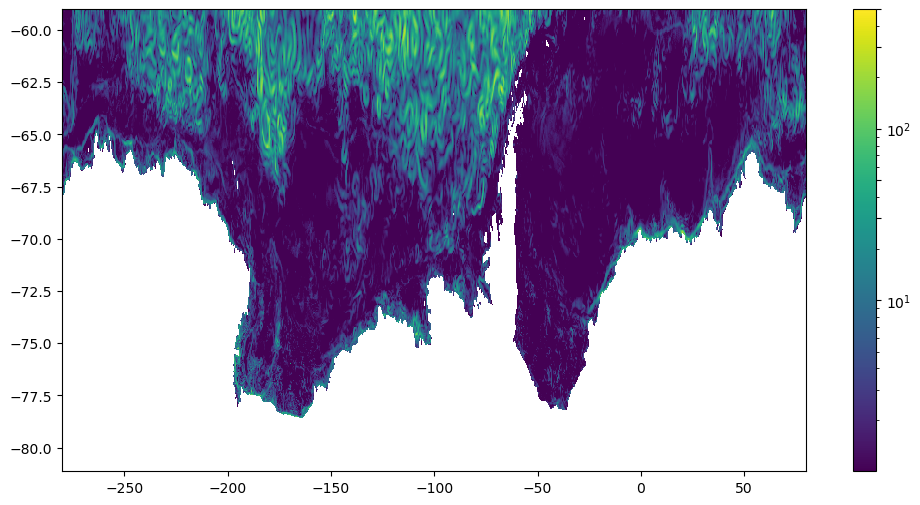

In [14]:
import matplotlib
plt.figure(figsize=(12,6))
plt.pcolormesh(EKE_3d.xq,EKE_3d.yh,EKE_3d.mean('time').sum('rho2_l'),norm=matplotlib.colors.LogNorm(vmin=1,vmax=5*100))
plt.colorbar(ticks=[1e1,3e1,5e1,1e2,3e2,5e2])

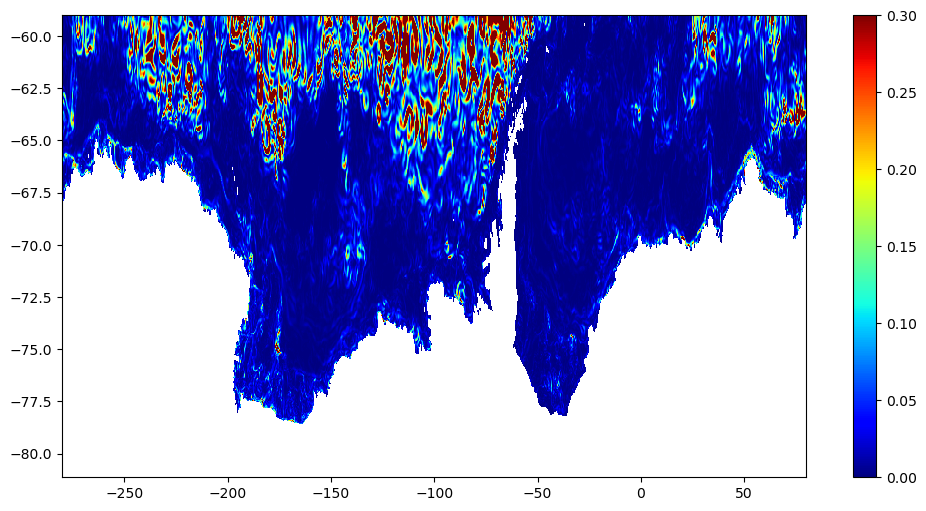

In [15]:
plt.figure(figsize=(12,6))
plt.pcolormesh(EKE_3d.xq,EKE_3d.yh,EKE_3d.mean('time').weighted(vol_forplot.fillna(0)).mean('rho2_l'),vmin=0,vmax=0.3,cmap='jet')
plt.colorbar()

In [16]:
EKE_3d_xhyh = EKE_3d.drop_vars('xh').interp(xq=vorticity.xh)

(-0.0001, 0.0001)

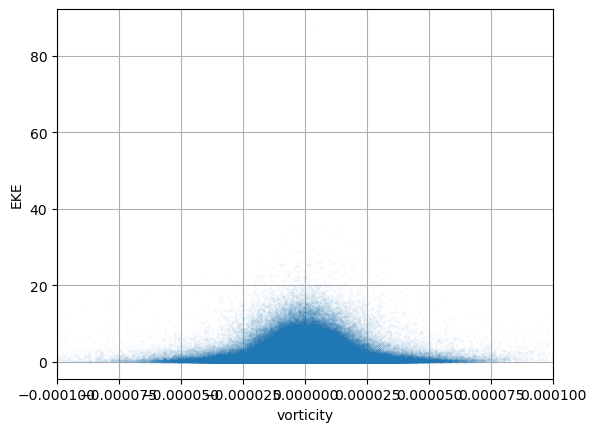

In [17]:
plt.plot(np.array(vorticity).flatten(),np.array(EKE_3d_xhyh).flatten(),\
         linestyle='none',marker='.',markersize = .05)
plt.grid()
plt.xlabel('vorticity')
plt.ylabel('EKE')
plt.xlim(-1e-4,1e-4)

**I think the EKE I calculated it is not correct, since I used U instead of U anomali. And teh vorticity, although not wrong, it is not ideal too, because within a month and in wigma levels, the eddy might change direction, and cancel out any signal ( which probably explain the low vorticities I find. We do have SSH daily, so Lets use the std of daily SSh to track the eddies then. This is not perfect, but is the best we can do**

In [18]:
#importing heat transports for the grid along the isobath
#panan01 daily as f(z,time)
src_p01 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/CSHT_month_rhoonline/*'
#panan005 daily as f(z,time)
src_p005 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/*'
#panan0025 daily as f(z,time)
src_p0025 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025/CSHT_month_rhoonline/*'

lat_slice  = slice(-83,-59)

figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'


#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HTmean=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time')
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_HTmean=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time')
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')

# #importing panan0025
# gl =glob.glob(src_p0025)
# gl=sorted(gl)
# print("%i netcdf data files"%len(gl))
# p0025_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').mean('time')

36 netcdf data files
36 netcdf data files


Interpolating panan01 velocities into the contour, and then the Eddy Kinectic Energy (EKE)

In [19]:
# Panan01
U_along_contour_01 = U_xq.interp(xq=p01_HTmean.lon_along_contour,\
                                 yh=p01_HTmean.lat_along_contour,method='nearest')\
.drop_vars({'xh','xq','yh'})
V_along_contour_01 = V_yq.interp(xh=p01_HTmean.lon_along_contour,\
                                 yq=p01_HTmean.lat_along_contour,method='nearest')\
.drop_vars({'xh','yq','yh'})

In [21]:
EKE_01 = 0.5 * ((U_along_contour_01**2) + (V_along_contour_01**2))
EKE_01.name = 'EKE_m2s2'

## Binning into the same 3 degrees as the zonal convergence

In [22]:
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
lon_along_contour = np.array(p01_HTmean.lon_along_contour)
lat_along_contour = np.array(p01_HTmean.lat_along_contour)
EKE_01_np=np.array(EKE_01.isel(time=0))
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)

# sum into longitude bins:
# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
# on the isobath contour and sum continously along contour between defined indices.
# (i.e. lon_along_contour is not monotonic)
# find points on contour to define edges of longitude bins:
bin_edge_indices = np.zeros(n_bin_edges)
for lon_bin in range(n_bin_edges-1):
    # find first isobath point that has the right longitude:
    first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
    # then find all other isobath points with the same longitude as that first point:
    same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
    # we want the most southerly of these points on the same longitude line:
    bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]

# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

# sum heat transport from isobath coord into new longitude coord:
EKE_3degbins = np.zeros([99,n_bins])
for lon_bin in range(n_bins):
	EKE0 = EKE_01_np[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	EKE_3degbins[:,lon_bin] = np.sum(EKE0,axis=1)
factor = np.nansum(EKE_01_np) / np.nansum(EKE_3degbins)

EKE_3degbins = EKE_3degbins * factor

In [23]:
p01_binnedEKE = p01_HT.sel(time=slice(start_time0,end_time0)).binned_cross_slope_heat_trans.copy()
p01_binnedEKE.values =np.expand_dims(EKE_3degbins,axis=0)
p01_binnedEKE.name =  'EKE_binned_m2s2'

In [24]:
EKE_01_tosave = xr.merge((p01_binnedEKE,EKE_01))

In [27]:
#saving file
dir_file = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/EKE_along_contour_rho/'
name_file = dir_file + 'EKE_along_contour_rho_' + start_time + '.nc'
EKE_01_tosave['factor']= factor

EKE_01_tosave.to_netcdf(name_file)


#visual check
EKE_01_tosave

PermissionError: [Errno 13] Permission denied: '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/EKE_along_contour_rho/EKE_along_contour_rho_2000-12.nc'

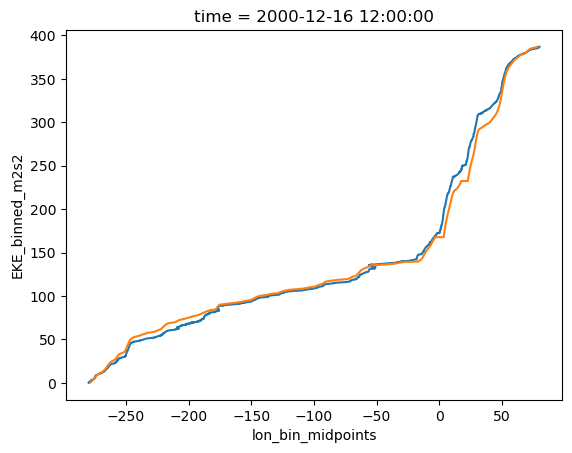

In [26]:
plt.plot(lon_along_contour,EKE_01_tosave.EKE_m2s2.isel(time=0).sum('rho2_l').cumsum())

EKE_01_tosave.EKE_binned_m2s2.isel(time=0).sum('rho2_l').cumsum().plot()